# Project: Startup Risk Aanalyzer

Startup Risk Analyzer is an end-to-end Machine Learning project that predicts whether a startup will succeed or fail based on key business metrics like funding, revenue, burn rate, team size, and market potential. The goal is to provide data-driven risk assessment for investors, founders, and venture capital firms. The project covers the complete ML pipeline — from EDA and preprocessing to model training with XGBoost, evaluation, and deployment via a Streamlit dashboard.

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

# 1. Load Data

In [2]:
df = pd.read_csv('../data/raw/startup_success_dataset.csv')

# 2. Data Exploration

In [3]:
df.head()

,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million,investor_type,sector,founder_background,outcome
0,4,13,58,48.225483,594843,18.519211,1.483962e+06,tier2_vc,Health,academic,IPO
1,1,6,221,31.532647,393020,14.298149,8.620568e+05,tier2_vc,Fintech,first_time,Failure
2,3,5,247,4.969722,27636,20.447567,9.726169e+04,none,SaaS,first_time,Failure
3,3,14,229,3.084209,235376,8.177417,1.145785e+06,none,Ecommerce,ex_bigtech,Acquisition
4,1,17,235,13.818188,391765,4.879792,8.608949e+05,none,Health,first_time,Acquisition


In [4]:
df.groupby('outcome')[
    [
        'revenue_million',
        'burn_rate_million',
        'product_traction_users',
        'funding_rounds'
    ]
].mean()

,revenue_million,burn_rate_million,product_traction_users,funding_rounds
outcome,,,,
Acquisition,1.041604e+06,16.833880,350871.971844,2.346593
Failure,5.363789e+05,16.715743,225905.483097,1.703363
IPO,2.120475e+06,17.224596,547695.586375,2.999027


In [22]:
df.groupby('outcome')[
    [
        'founder_experience_years',
        'team_size',
        'market_size_billion'
    ]
].mean()

,founder_experience_years,team_size,market_size_billion
outcome,,,
0,10.745208,143.463676,33.084890
1,13.626695,159.837463,33.352935


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   funding_rounds            100000 non-null  int64  
 1   founder_experience_years  100000 non-null  int64  
 2   team_size                 100000 non-null  int64  
 3   market_size_billion       100000 non-null  float64
 4   product_traction_users    100000 non-null  int64  
 5   burn_rate_million         100000 non-null  float64
 6   revenue_million           100000 non-null  float64
 7   investor_type             100000 non-null  object 
 8   sector                    100000 non-null  object 
 9   founder_background        100000 non-null  object 
 10  outcome                   100000 non-null  object 
dtypes: float64(3), int64(4), object(4)
memory usage: 8.4+ MB


# Dataset Description
---
### Source
Kaggle — Startup Funding and Outcome Dataset

### Shape
1,00,000 rows × 11 columns

### Feature Description

| Column | Type | Description |
|--------|------|-------------|
| `funding_rounds` | Numeric | Number of funding rounds completed |
| `founder_experience_years` | Numeric | Years of experience of the founder |
| `team_size` | Numeric | Total number of team members |
| `market_size_billion` | Numeric | Target market size in billion USD |
| `product_traction_users` | Numeric | Number of active product users |
| `burn_rate_million` | Numeric | Monthly cash burn in million USD |
| `revenue_million` | Numeric | Monthly revenue in million USD |
| `investor_type` | Categorical | Type of investor (VC, Angel, etc.) |
| `sector` | Categorical | Industry sector of the startup |
| `founder_background` | Categorical | Founder's professional background |
| `outcome` | Target | Whether startup Succeeded or Failed |

In [6]:
# Check Target Column
df['outcome'].value_counts()

outcome
Failure        55610
Acquisition    42335
IPO             2055
Name: count, dtype: int64

In [7]:
# Check Categorical Column
print(df['investor_type'].value_counts())
print()
print(df['sector'].value_counts())
print()
print(df['founder_background'].value_counts())

investor_type
tier2_vc    35327
angel       25137
none        24866
tier1_vc    14670
Name: count, dtype: int64

sector
Crypto       14456
Climate      14412
Health       14357
SaaS         14333
Fintech      14220
Ecommerce    14148
AI           14074
Name: count, dtype: int64

founder_background
first_time        39980
ex_bigtech        25009
academic          20054
serial_founder    14957
Name: count, dtype: int64


# Categorical Feature Values — Explained
---
### `investor_type`
| Value | Meaning |
|-------|---------|
| `tier1_vc` | Top-tier VC firms (Sequoia, Accel) — highest credibility funding |
| `tier2_vc` | Mid-level VC firms — professional but less prestigious |
| `angel` | Individual wealthy investors investing personal capital |
| `none` | No external investor — bootstrapped startup |

### `sector`
| Value | Meaning |
|-------|---------|
| `Crypto` | Blockchain, cryptocurrency, Web3 startups |
| `Climate` | Clean energy, environmental technology startups |
| `Health` | Healthcare and medical technology startups |
| `SaaS` | Subscription-based software products |
| `Fintech` | Financial technology startups (payments, lending) |
| `Ecommerce` | Online retail and marketplace startups |
| `AI` | Artificial Intelligence product companies |

### `founder_background`
| Value | Meaning |
|-------|---------|
| `first_time` | First-time founder, no prior startup experience |
| `ex_bigtech` | Previously worked at Google, Amazon, Microsoft etc. |
| `academic` | University or research background |
| `serial_founder` | Has built startups before |

### `outcome` — Target Variable
| Value | Meaning |
|-------|---------|
| `Failure` | Startup shut down — ran out of money or failed to grow |
| `Acquisition` | Bought by a larger company — successful exit |
| `IPO` | Listed on stock market — highest level of startup success |

# 3. EDA

### 3.1 - Statistics

In [8]:
df.describe()

,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05
mean,2.002300,12.024300,150.732000,33.203875,285422.832730,16.776213,7.828191e+05
std,1.414671,7.208089,86.272631,43.034753,159323.885405,15.711368,6.085069e+05
min,0.000000,0.000000,2.000000,0.288738,668.000000,0.279763,1.344810e+03
25%,1.000000,6.000000,76.000000,10.196778,161194.750000,7.087591,3.154861e+05
50%,2.000000,12.000000,151.000000,20.158063,264989.500000,12.169059,6.213624e+05
75%,3.000000,18.000000,226.000000,39.531967,389214.000000,20.953561,1.098921e+06
max,8.000000,24.000000,299.000000,1072.434476,915203.000000,357.491454,4.168443e+06


### 3.2 - Check Missing Values

In [9]:
df.isnull().sum()

funding_rounds              0
founder_experience_years    0
team_size                   0
market_size_billion         0
product_traction_users      0
burn_rate_million           0
revenue_million             0
investor_type               0
sector                      0
founder_background          0
outcome                     0
dtype: int64

### 3.3 - Check Duplicate Values

In [10]:
df.duplicated().sum()

np.int64(0)

### 3.4 - Outlier Detection

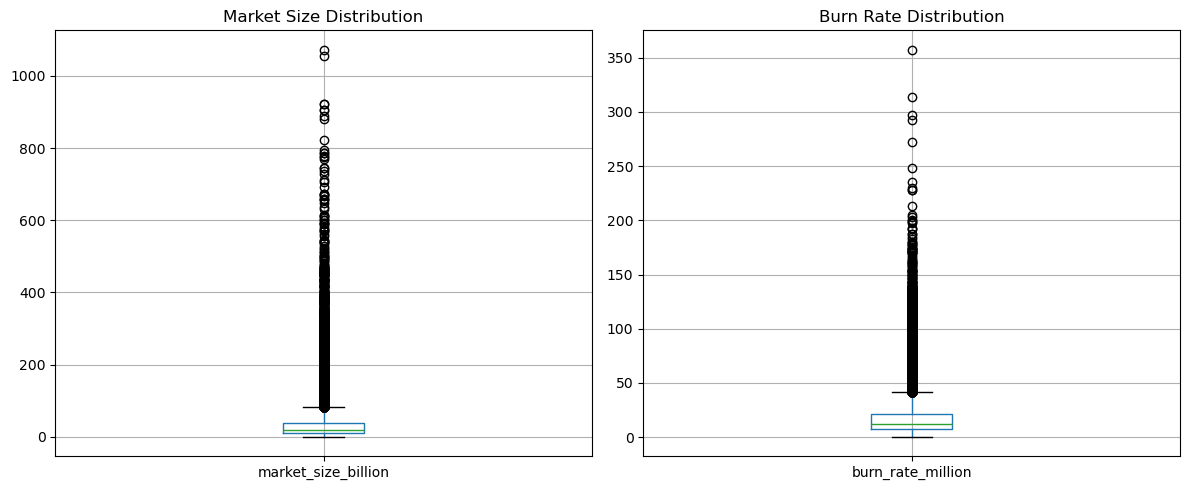

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df.boxplot(column='market_size_billion', ax=axes[0])
axes[0].set_title('Market Size Distribution')

df.boxplot(column='burn_rate_million', ax=axes[1])
axes[1].set_title('Burn Rate Distribution')

plt.tight_layout()
plt.show()
plt.close()

In [12]:
# Check Outliers using IQR 
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

for col in numeric_cols: 
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR 
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"{col}: {outliers} outliers")

funding_rounds: 470 outliers
founder_experience_years: 0 outliers
team_size: 0 outliers
market_size_billion: 7811 outliers
product_traction_users: 624 outliers
burn_rate_million: 6186 outliers
revenue_million: 2888 outliers


### 3.5 - Boxplot Visualization

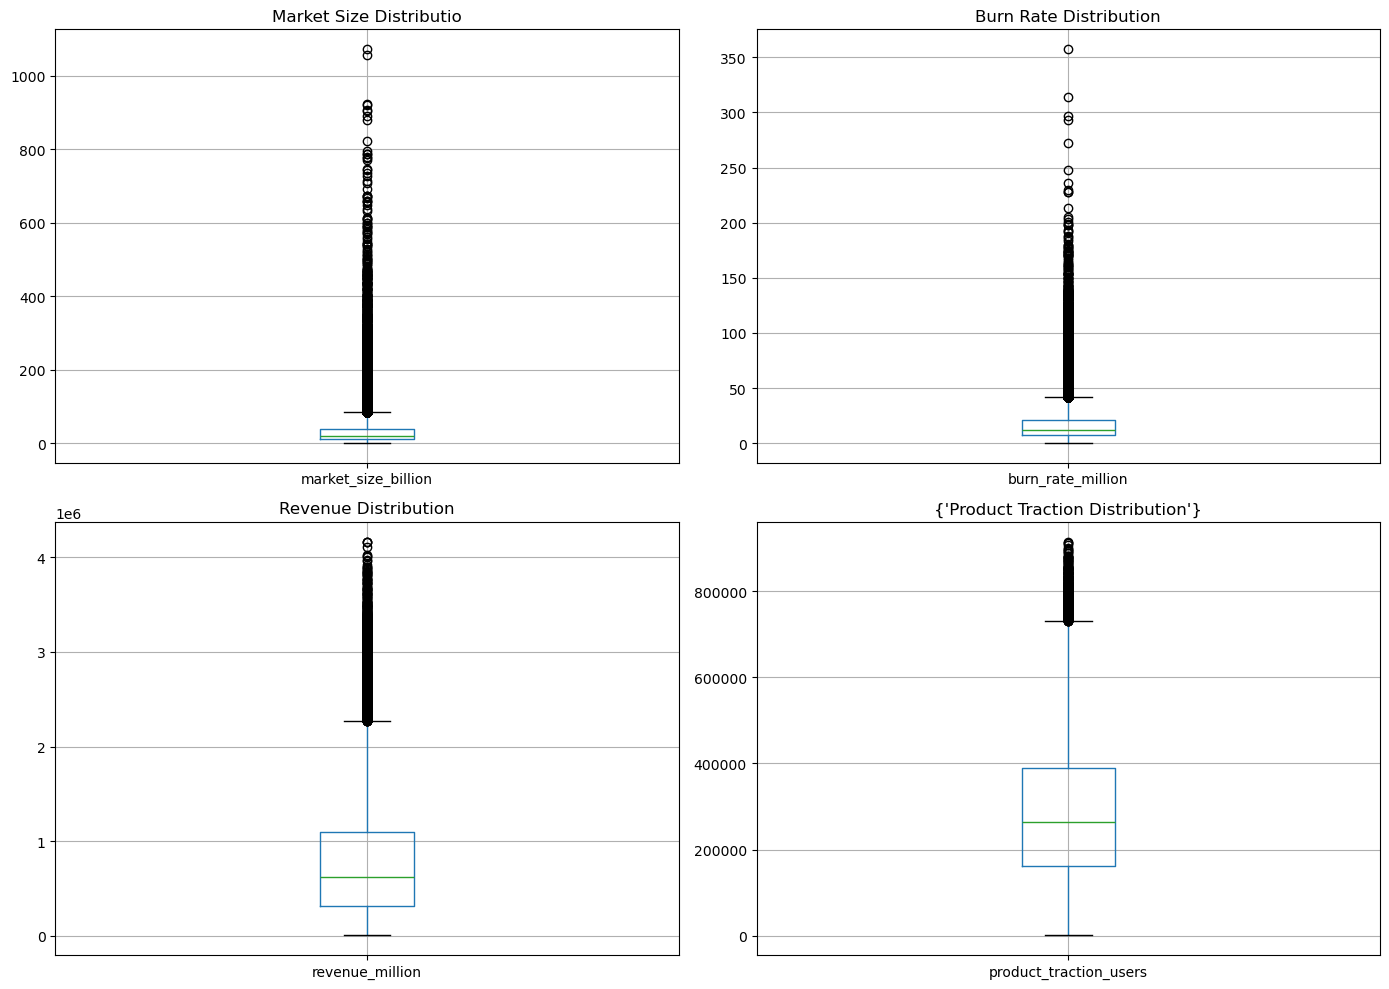

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df.boxplot(column='market_size_billion', ax=axes[0][0])
axes[0][0].set_title('Market Size Distributio')

df.boxplot(column='burn_rate_million', ax=axes[0][1])
axes[0][1].set_title("Burn Rate Distribution")

df.boxplot(column='revenue_million', ax=axes[1][0])
axes[1][0].set_title("Revenue Distribution")

df.boxplot(column='product_traction_users', ax=axes[1][1])
axes[1][1].set_title({'Product Traction Distribution'})

plt.tight_layout()
plt.show()
plt.close()

### 3.5 - Binary Encoding of Target

In [14]:
df['outcome'] = df['outcome'].map({'Failure': 0, 'Acquisition': 1, 'IPO': 1})
df['outcome'].value_counts()

outcome
0    55610
1    44390
Name: count, dtype: int64

### 3.6 - Target Variable Distribution

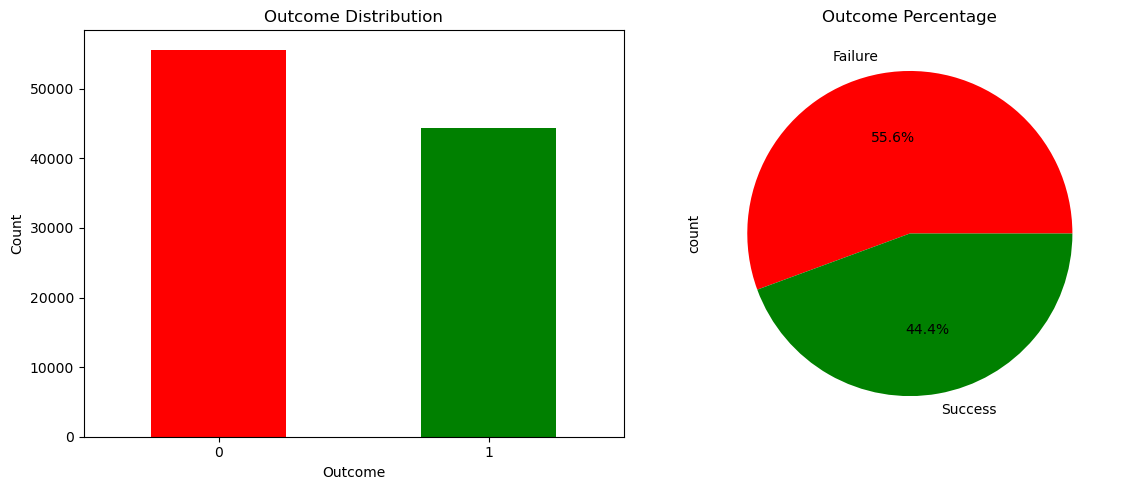

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count Plot
df['outcome'].value_counts().plot(kind='bar', ax=axes[0], color=['red', 'green'])
axes[0].set_title('Outcome Distribution')
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Percentage pie chart
df['outcome'].value_counts().plot(kind='pie', ax=axes[1],
                                 labels=['Failure', 'Success'],
                                 autopct='%1.1f%%',
                                 colors=['red', 'green'])
axes[1].set_title('Outcome Percentage')

plt.tight_layout()
plt.show()
plt.close()

### 3.7 - Numeric Features Distribution

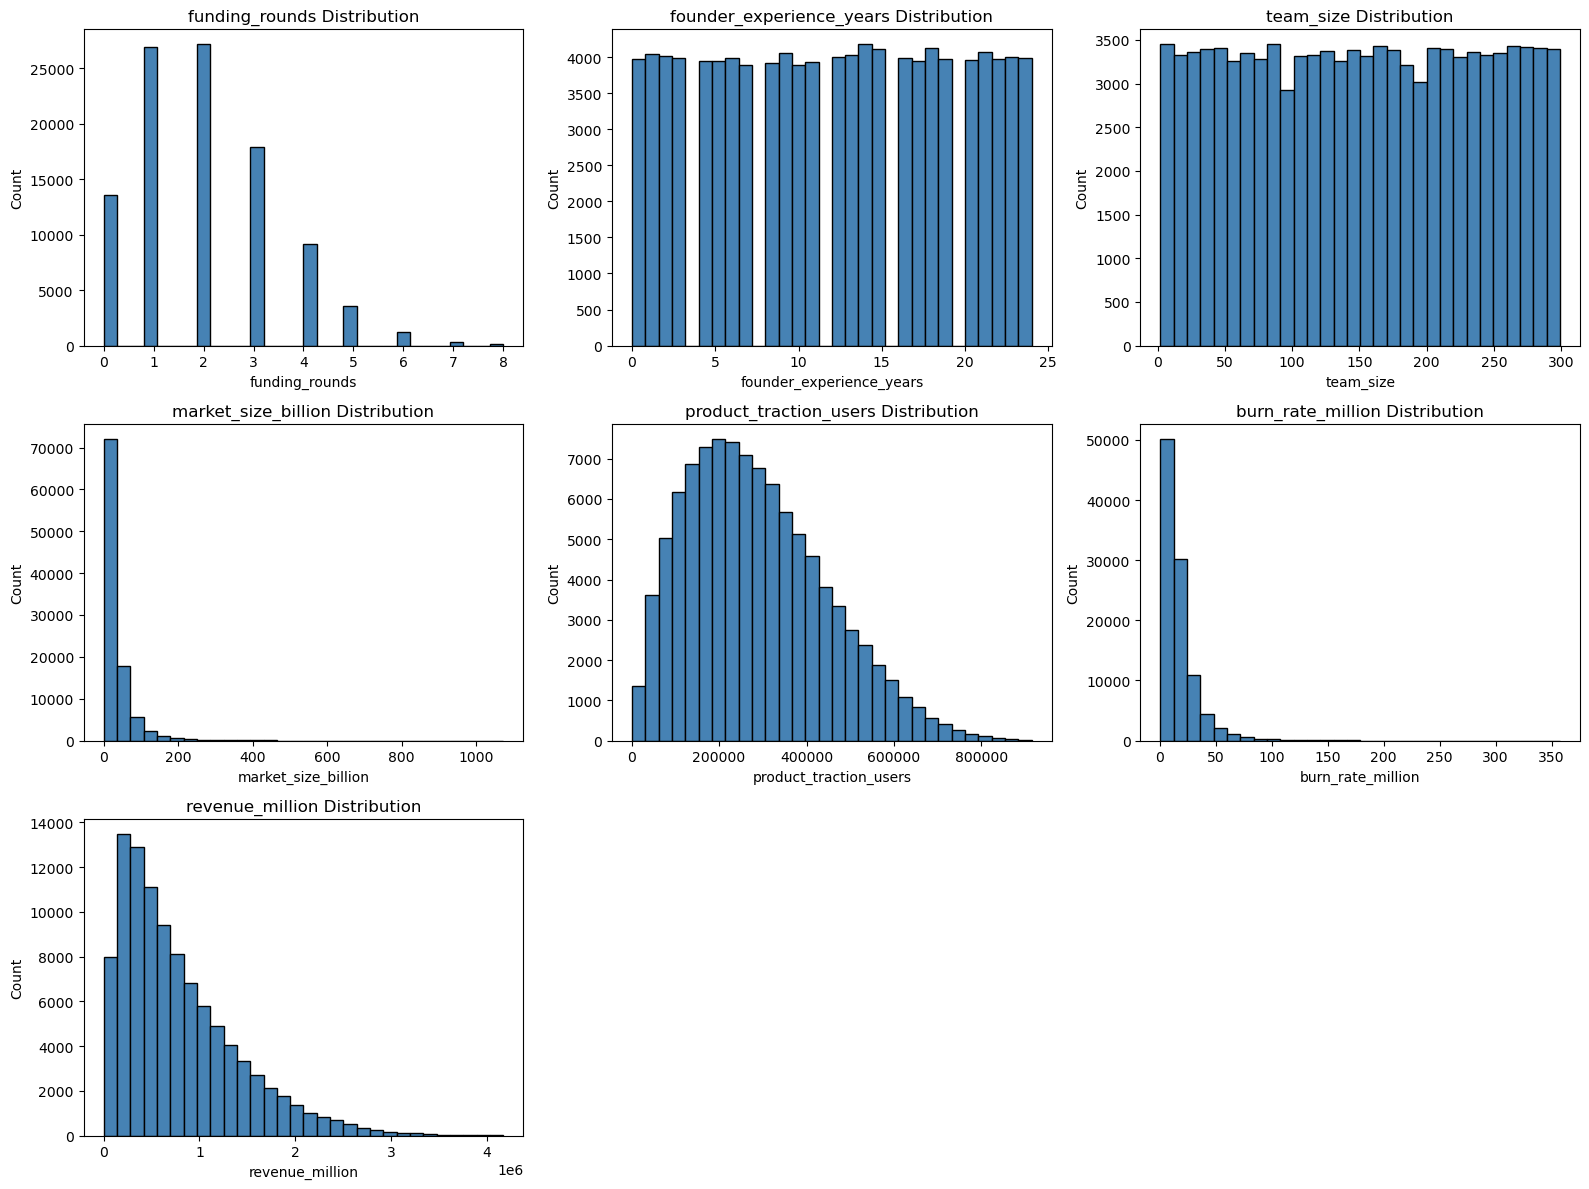

In [16]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols.remove('outcome')

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

# flatten — converts 2D array of axes to 1D for easy indexing
axes = axes.flatten()  

# enumerate — returns index and value together while iterating
for i, col in enumerate(numeric_cols):  
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

for j in range(len(numeric_cols), len(axes)): 
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()
plt.close()

### 3.8 - Categorical Features Distribution

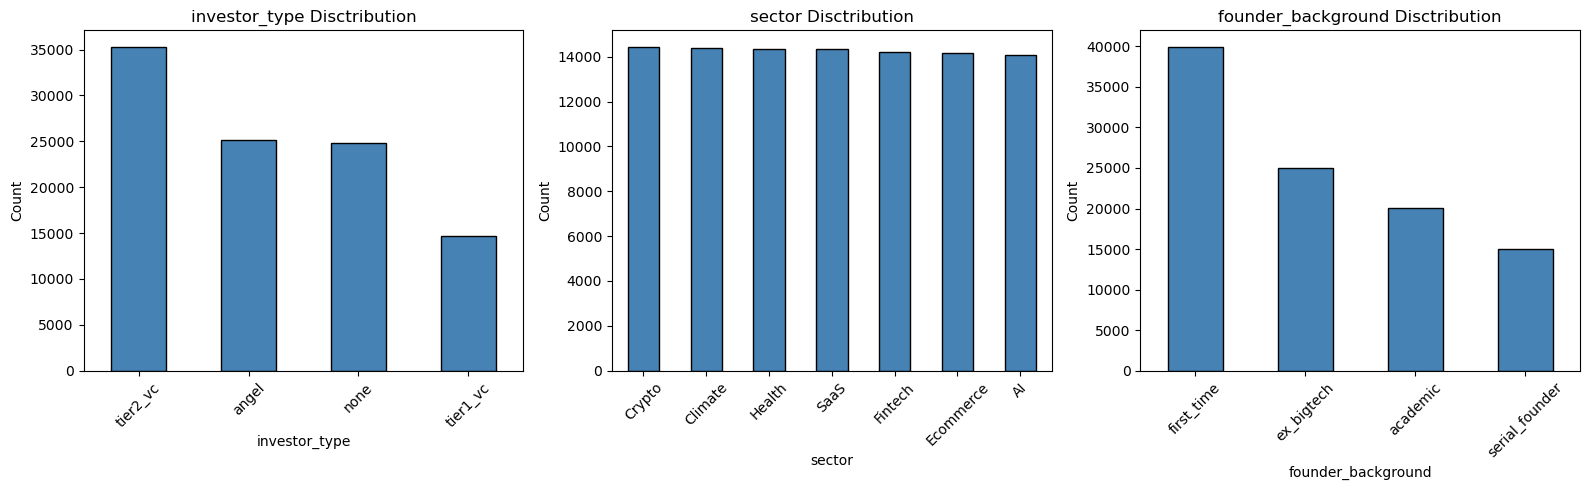

In [17]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# enumerate — returns index and value together while iterating
for i, col in enumerate(cat_cols):  
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'{col} Disctribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
plt.close()

### 3.9 - Correlation Heatmap

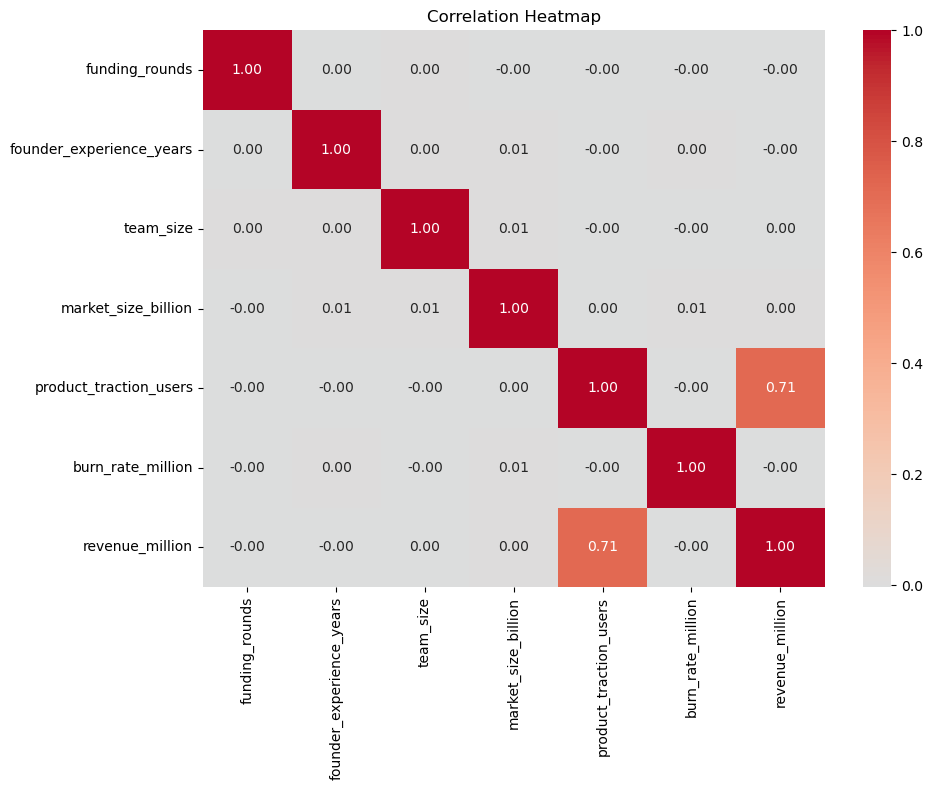

In [18]:
plt.figure(figsize=(10, 8))

sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()
plt.close()

### 3.10 - Feature vs Outcome Analaysis

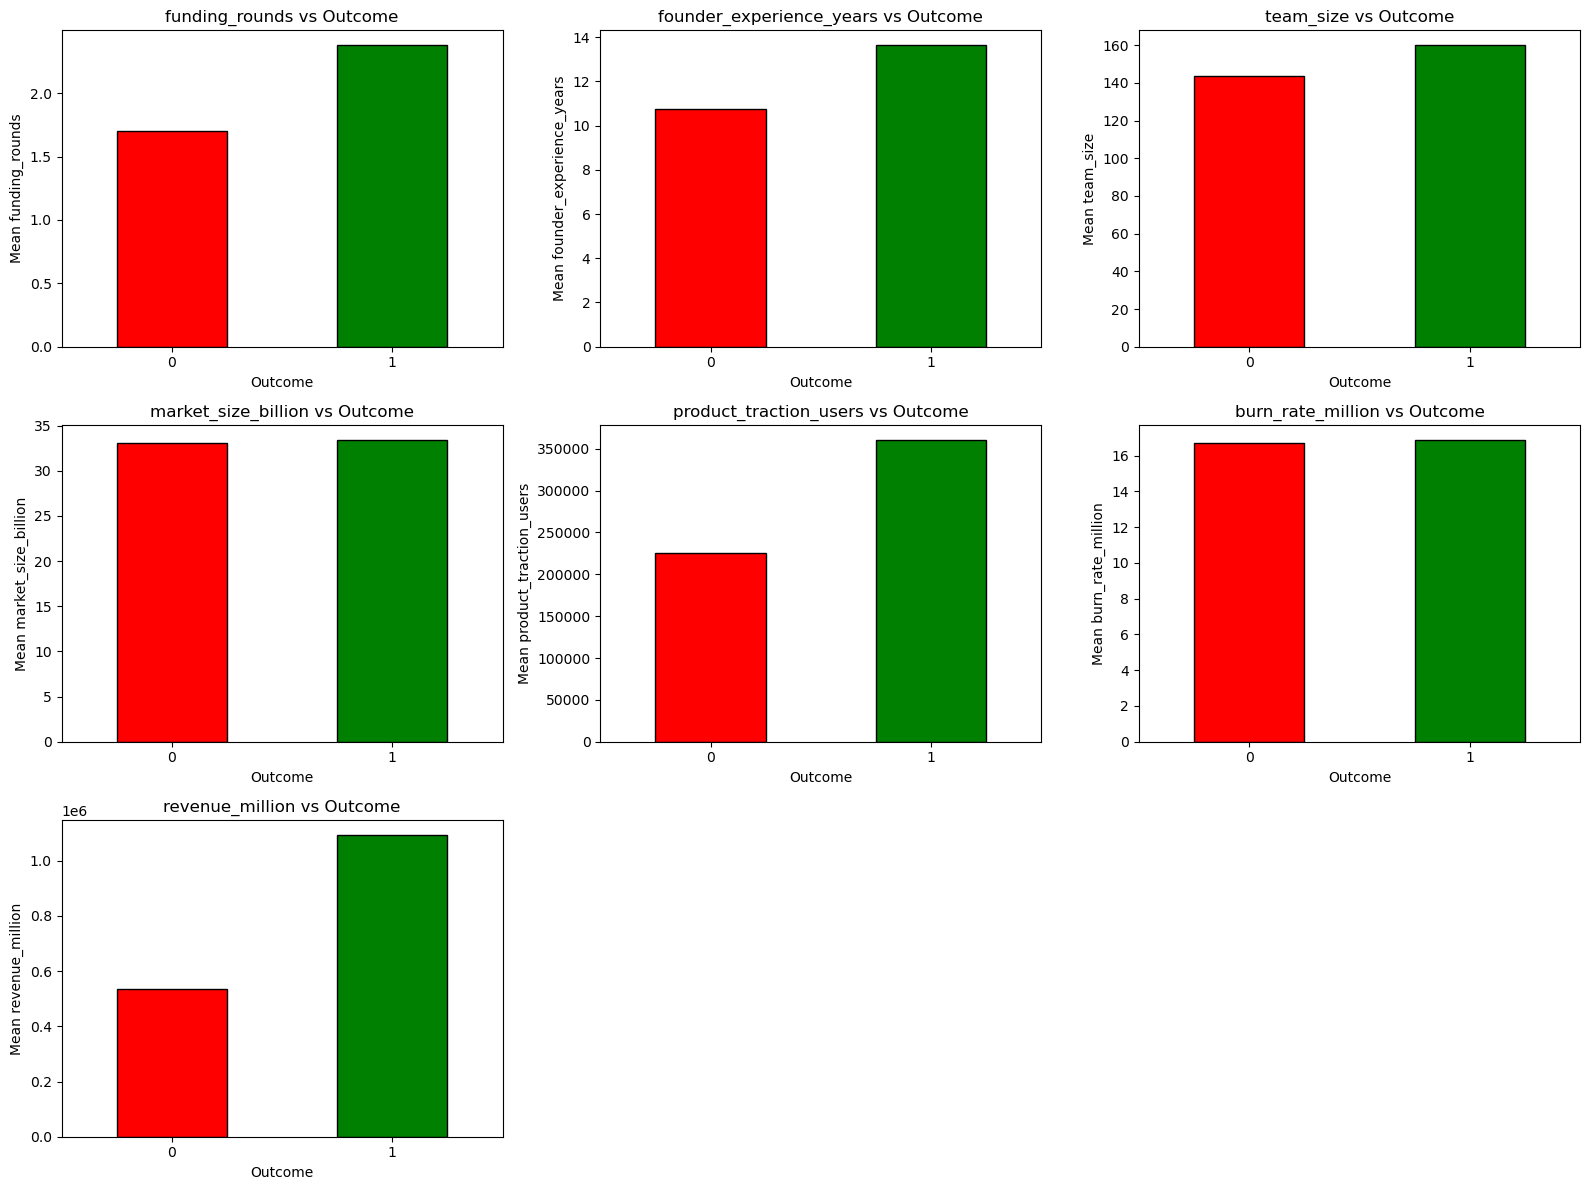

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

# flatten — converts 2D array of axes to 1D for easy indexing
axes = axes.flatten()  

# enumerate — returns index and value together while iterating
for i, col in enumerate(numeric_cols):  
    # groupby — groups rows by outcome value, then calculates mean for each group
    df.groupby('outcome')[col].mean().plot(kind='bar', ax=axes[i], color=['red', 'green'], edgecolor='black')
    axes[i].set_title(f'{col} vs Outcome')
    axes[i].set_xlabel('Outcome')
    axes[i].set_ylabel(f'Mean {col}')
    axes[i].tick_params(axis='x', rotation=0)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()
plt.close()

### 3.11 - Categorical Features vs Outcome

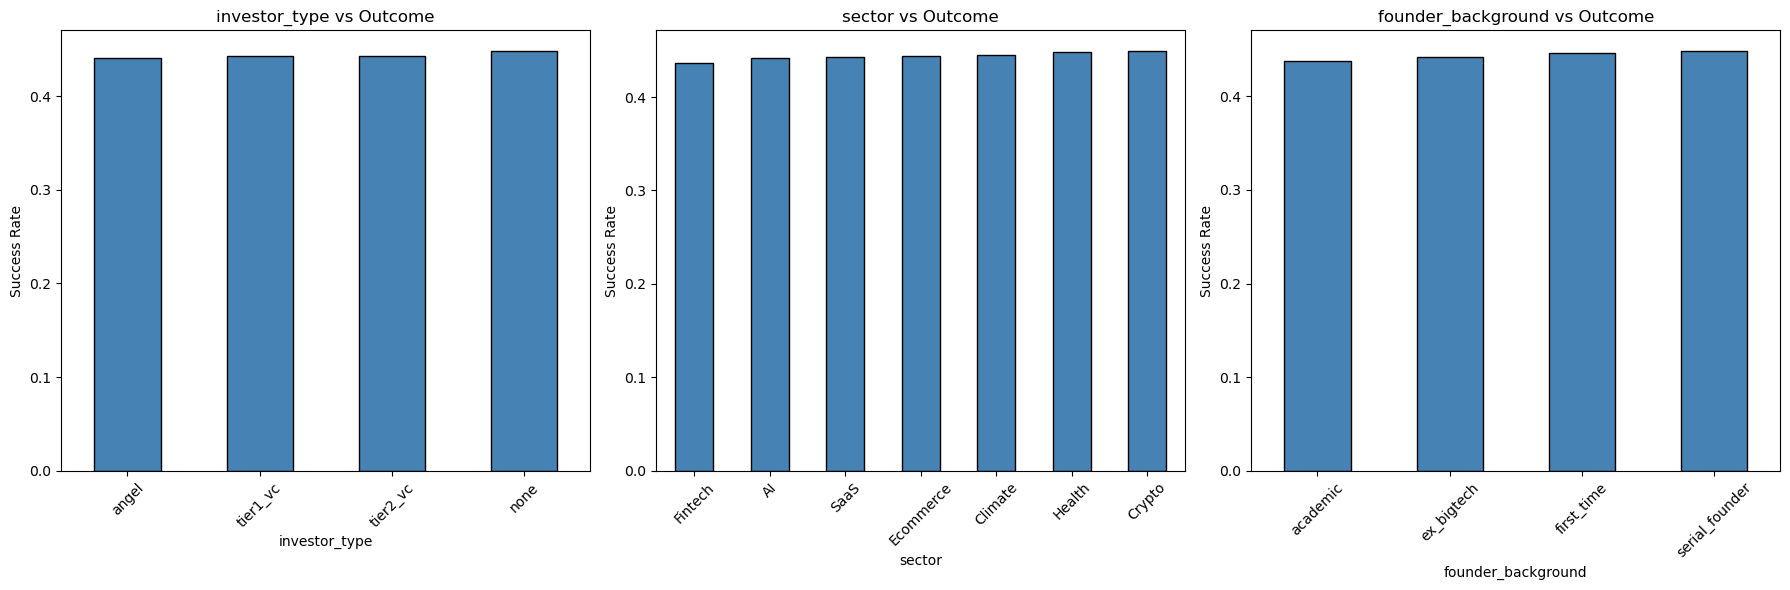

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# enumerate — returns index and value together while iterating
for i, col in enumerate(cat_cols):  
    # groupby — groups rows by outcome value, then calculates mean for each group
    df.groupby(col)['outcome'].mean().sort_values().plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'{col} vs Outcome') 
    axes[i].set_xlabel(col) 
    axes[i].set_ylabel('Success Rate')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
plt.close()

In [21]:
df[numeric_cols + ['outcome']].corr()['outcome'].sort_values(ascending=False)

outcome                     1.000000
revenue_million             0.453296
product_traction_users      0.418118
funding_rounds              0.236516
founder_experience_years    0.198618
team_size                   0.094297
burn_rate_million           0.004308
market_size_billion         0.003095
Name: outcome, dtype: float64

## EDA Summary — Key Findings

- No missing values or duplicates found in the dataset
- Slight class imbalance: 55.6% Failure vs 44.4% Success — acceptable
- Outliers present in market_size_billion and burn_rate_million — retained as XGBoost handles them
- Revenue and product traction are strongest predictors of startup success
- Burn rate alone has negligible correlation with outcome
- Market size has almost zero correlation — execution matters more than opportunity size